#  Preprocessing, Modeling, dan Evaluasi

Catatan: Notebook ini merupakan lanjutan dari bagian EDA (pada notebook 01_eda_sepsis.ipynb) yang menghasilkan df_balanced.cs.

In [2]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
)

c:\Users\ASUS\anaconda3\envs\kds\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
df_balanced = pd.read_csv("../data/df_balanced.csv")
print(f"Shape: {df_balanced.shape}")
print(df_balanced["SepsisLabel"].value_counts().to_string())

Shape: (277653, 57)
SepsisLabel
0    260165
1     17488


## 3. Preprocessing - Feature Selection dan Scaling

Tahap ini mempersiapkan df_balanced menjadi matriks numerik yang siap dilatih MLP dalam tiga sub-tahap:
1. Visualisasi korelasi penuh dan deteksi administrative leakage (ICULOS, HospAdmTime, dll).
2. Feature selection: drop kolom administratif dan prune fitur dengan |r| > 0.95.
3. Stratified split dengan komposisi 80/20 dan StandardScaler yang hanya di-fit pada training set.

### 3.1 Full Correlation Heatmap dan Leakage Detection

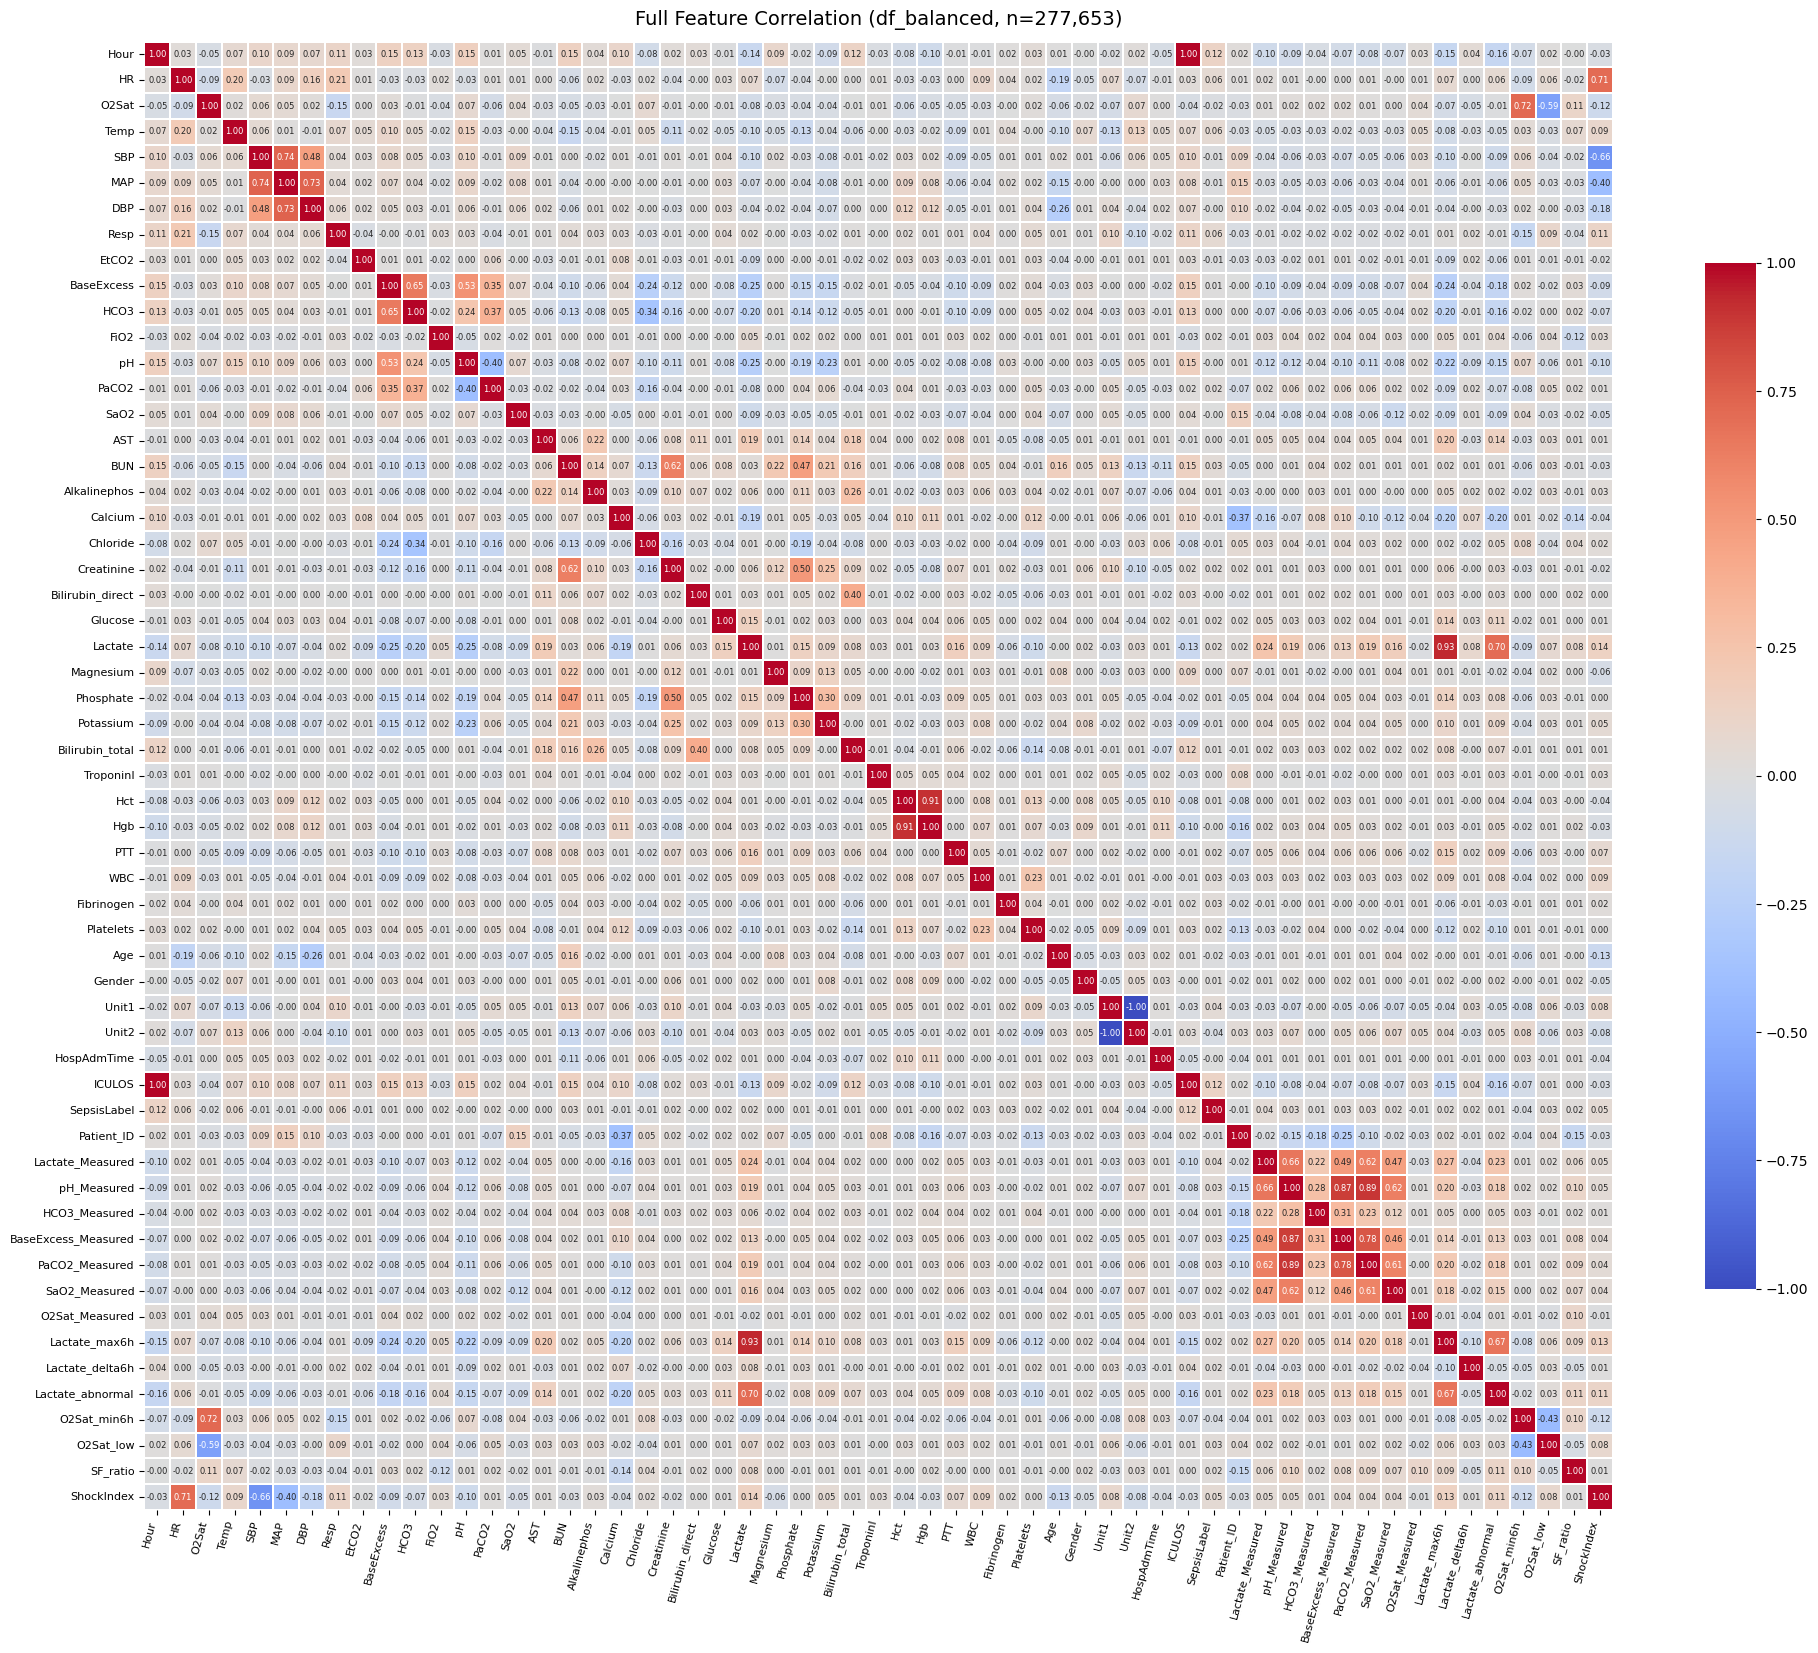


Top-10 |Pearson r| vs SepsisLabel (df_balanced):
ICULOS              0.121
Hour                0.121
Temp                0.057
HR                  0.057
Resp                0.056
ShockIndex          0.050
Unit2               0.042
Unit1               0.042
Lactate_Measured    0.040
O2Sat_min6h         0.037


In [20]:
corr_full = df_balanced.corr(method="pearson", numeric_only=True)

fig, ax = plt.subplots(figsize=(20, 18))
sns.heatmap(
    corr_full,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 6},
    square=True,
    cbar_kws={"shrink": 0.6},
    linewidths=0.3,
    linecolor="white",
    ax=ax,
)
ax.set_title(f"Full Feature Correlation (df_balanced, n={len(df_balanced):,})", fontsize=14, pad=12)
plt.xticks(rotation=75, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()

os.makedirs("../reports", exist_ok=True)
heatmap_path = "../reports/full_feature_heatmap.png"
plt.savefig(heatmap_path, dpi=200, bbox_inches="tight")
plt.show()

label_corr = corr_full["SepsisLabel"].drop("SepsisLabel").abs().sort_values(ascending=False)
print("\nTop-10 |Pearson r| vs SepsisLabel (df_balanced):")
print(label_corr.head(10).round(3).to_string())

Heatmap di atas menunjukkan multikolinearitas klinis yang diharapkan, misalnya Hct dan Hgb yang keduanya mengukur konsentrasi sel darah merah. Kolom administratif seperti ICULOS dan HospAdmTime muncul di Top-10 korelasi terhadap SepsisLabel dan akan dibuang di subsection berikutnya.

### 3.2 Feature Selection: Drop Kolom Administratif dan Fitur Redundan

In [9]:
ADMIN_COLS = ["Patient_ID", "ICULOS", "Hour", "HospAdmTime", "Unit1", "Unit2"]
DEMOGRAPHIC_DROP = ["Age", "Gender"]
DROP_COLS = ADMIN_COLS + DEMOGRAPHIC_DROP

df_feat = df_balanced.drop(columns=[c for c in DROP_COLS if c in df_balanced.columns]).copy()
df_feat = df_feat.loc[:, ~df_feat.columns.str.startswith("Unnamed")]
print(f"After admin+demographic drop: {df_feat.shape[1]} columns ({df_feat.shape[0]:,} rows)")

raw_missing_pct = (df_balanced.isna().mean() * 100).to_dict()

REDUNDANCY_THRESHOLD = 0.95
feat_only = df_feat.drop(columns=["SepsisLabel"])
corr_feat = feat_only.corr().abs()
cols = sorted(corr_feat.columns.tolist())
corr_feat = corr_feat.loc[cols, cols]

redundant_drops = []
dropped_set = set()
for i, a in enumerate(cols):
    if a in dropped_set:
        continue
    for b in cols[i + 1:]:
        if b in dropped_set:
            continue
        r = corr_feat.loc[a, b]
        if r > REDUNDANCY_THRESHOLD:
            miss_a = raw_missing_pct.get(a, float("nan"))
            miss_b = raw_missing_pct.get(b, float("nan"))
            if miss_a > miss_b:
                drop, keep = a, b
            elif miss_b > miss_a:
                drop, keep = b, a
            else:
                drop, keep = sorted([a, b])[1], sorted([a, b])[0]
            redundant_drops.append(drop)
            dropped_set.add(drop)
            print(f"  Pair |r|={r:.3f}: {a} vs {b} -> DROP {drop}, KEEP {keep}")
            if a == drop:
                break

if not redundant_drops:
    print("  (no pairs exceeded threshold)")

df_feat = df_feat.drop(columns=redundant_drops)

final_features = sorted(df_feat.drop(columns=["SepsisLabel"]).columns.tolist())
print(f"\nFeature count (excl. target): {len(final_features)}")
for c in final_features:
    print(f"  - {c}")

After admin+demographic drop: 49 columns (277,653 rows)
  (no pairs exceeded threshold)

Feature count (excl. target): 48
  - AST
  - Alkalinephos
  - BUN
  - BaseExcess
  - BaseExcess_Measured
  - Bilirubin_direct
  - Bilirubin_total
  - Calcium
  - Chloride
  - Creatinine
  - DBP
  - EtCO2
  - FiO2
  - Fibrinogen
  - Glucose
  - HCO3
  - HCO3_Measured
  - HR
  - Hct
  - Hgb
  - Lactate
  - Lactate_Measured
  - Lactate_abnormal
  - Lactate_delta6h
  - Lactate_max6h
  - MAP
  - Magnesium
  - O2Sat
  - O2Sat_Measured
  - O2Sat_low
  - O2Sat_min6h
  - PTT
  - PaCO2
  - PaCO2_Measured
  - Phosphate
  - Platelets
  - Potassium
  - Resp
  - SBP
  - SF_ratio
  - SaO2
  - SaO2_Measured
  - ShockIndex
  - Temp
  - TroponinI
  - WBC
  - pH
  - pH_Measured


### 3.3 Stratified Split dan StandardScaler

In [10]:
feature_names = df_feat.drop(columns=["SepsisLabel"]).columns.tolist()
X_all = df_feat[feature_names].values.astype(np.float64)
y_all = df_feat["SepsisLabel"].astype(int).values
pid_all  = df_balanced["Patient_ID"].values
hour_all = df_balanced["Hour"].values

unique_pids = np.unique(pid_all)
pid_labels = (
    pd.Series(y_all).groupby(pid_all).max().reindex(unique_pids).values.astype(int)
)
train_pids, test_pids = train_test_split(
    unique_pids, test_size=0.20, stratify=pid_labels, random_state=42
)
is_train = np.isin(pid_all, train_pids)
X_train, y_train = X_all[is_train], y_all[is_train]
X_test,  y_test  = X_all[~is_train], y_all[~is_train]

test_pid  = pid_all[~is_train]
test_hour = hour_all[~is_train]

assert set(pid_all[is_train].tolist()).isdisjoint(set(pid_all[~is_train].tolist())), \
    "Patient leakage between train and test!"

pos_train_idx = np.flatnonzero(y_train == 1)
neg_train_idx = np.flatnonzero(y_train == 0)
n_repeat = max((len(neg_train_idx) // len(pos_train_idx)) - 1, 0)
oversample_idx = np.tile(pos_train_idx, n_repeat)
shuffled = np.concatenate([np.arange(len(y_train)), oversample_idx])
np.random.default_rng(42).shuffle(shuffled)
X_train = X_train[shuffled]
y_train = y_train[shuffled]
print(f"Post row-oversample - X_train: {X_train.shape} | pos% = {y_train.mean()*100:.2f}")

scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test  = scaler.transform(X_test)

assert np.isfinite(X_train).all() and np.isfinite(X_test).all()

print(f"X_train: {X_train.shape} | pasien={len(train_pids):,}")
print(f"X_test : {X_test.shape}  | pasien={len(test_pids):,}")
print(f"y_test : pos={int(y_test.sum())} ({y_test.mean()*100:.2f}%)")

os.makedirs("../data", exist_ok=True)
np.save("../data/X_train.npy", X_train)
np.save("../data/X_test.npy", X_test)
np.save("../data/y_train.npy", y_train)
np.save("../data/y_test.npy", y_test)
np.save("../data/feature_names.npy", np.array(feature_names))
np.save("../data/test_pid.npy", test_pid)
np.save("../data/test_hour.npy", test_hour)
print("Saved: data/{X_train,X_test,y_train,y_test,feature_names,test_pid,test_hour}.npy")

Post row-oversample - X_train: (403866, 48) | pos% = 48.56
X_train: (403866, 48) | pasien=4,365
X_test : (55891, 48)  | pasien=1,092
y_test : pos=3480 (6.23%)
Saved: data/{X_train,X_test,y_train,y_test,feature_names,test_pid,test_hour}.npy


## 4. Pelatihan Multi-Layer Perceptron

Arsitektur 3 hidden layer (64 neuron, 32 neuron, 16 neuron) dengan fungsi aktivasi ReLU dan optimizer Adam dipilih agar model dapat dengan cukup ekspresif  menangkap interaksi non-linear antar penanda metabolik (Lactate, O2Sat, BUN, Creatinine) tanpa mengalami overfitting terhadap dataset balanced 1:2. Early stopping dengan 10% validation hold-out dan n_iter_no_change=10 digunakan sebagai regularisasi implisit.

In [23]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32, 16),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    batch_size=256,
    learning_rate_init=1e-3,
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=42,
    verbose=True,
)
mlp.fit(X_train, y_train)

MODEL_PATH = "sepsis_mlp_model.pkl"
joblib.dump(mlp, MODEL_PATH)
print(f"\nConverged at iter {mlp.n_iter_} | best val score: {mlp.best_validation_score_:.4f}")
print(f"Saved model -> {MODEL_PATH}")

Iteration 1, loss = 0.60222683
Validation score: 0.714735
Iteration 2, loss = 0.52275862
Validation score: 0.753931
Iteration 3, loss = 0.47638026
Validation score: 0.773318
Iteration 4, loss = 0.44577215
Validation score: 0.794612
Iteration 5, loss = 0.42399529
Validation score: 0.803055
Iteration 6, loss = 0.40803460
Validation score: 0.811078
Iteration 7, loss = 0.39498324
Validation score: 0.818506
Iteration 8, loss = 0.38392579
Validation score: 0.823235
Iteration 9, loss = 0.37536249
Validation score: 0.830292
Iteration 10, loss = 0.36740103
Validation score: 0.833610
Iteration 11, loss = 0.36033364
Validation score: 0.837571
Iteration 12, loss = 0.35419392
Validation score: 0.841112
Iteration 13, loss = 0.34954112
Validation score: 0.840122
Iteration 14, loss = 0.34499328
Validation score: 0.849110
Iteration 15, loss = 0.34031330
Validation score: 0.841063
Iteration 16, loss = 0.33745173
Validation score: 0.846040
Iteration 17, loss = 0.33479134
Validation score: 0.846213
Iterat

## 5. Evaluasi Performa

Evaluasi dilakukan pada test set 20% yang belum pernah dilihat model. Empat plot diagnostik disimpan ke direktori reports/ untuk keperluan laporan: 
1. Loss curve dengan validation accuracy
2. Confusion matrix 
3. ROC curve (AUC) 
4. Precision-Recall curve (Average Precision)

In [11]:
y_proba_raw = mlp.predict_proba(X_test)[:, 1]

SMOOTH_WINDOW = 6
sort_idx = np.lexsort((test_hour, test_pid))
_df = pd.DataFrame({
    "pid": test_pid[sort_idx],
    "p":   y_proba_raw[sort_idx],
    "y":   y_test[sort_idx],
})
_df["p_smooth"] = _df.groupby("pid")["p"].transform(
    lambda s: s.rolling(window=SMOOTH_WINDOW, min_periods=1).mean()
)
y_proba = np.empty_like(y_proba_raw)
y_proba[sort_idx] = _df["p_smooth"].values
print(f"Temporal smoothing rolling-{SMOOTH_WINDOW}h: mean abs delta = {np.abs(y_proba - y_proba_raw).mean():.4f}")

TARGET_RECALL = 0.75
n_pos = int((y_test == 1).sum())
order = np.argsort(-y_proba)
cum_tp = np.cumsum(y_test[order] == 1)
mask = (cum_tp / n_pos) >= TARGET_RECALL
hour_threshold = float(y_proba[order][np.argmax(mask)]) if mask.any() else 0.0
y_pred = (y_proba >= hour_threshold).astype(int)

test_rec_h  = recall_score(y_test, y_pred)
test_spec_h = ((y_pred == 0) & (y_test == 0)).sum() / (y_test == 0).sum()
test_prec_h = precision_score(y_test, y_pred)
test_auc_h  = roc_auc_score(y_test, y_proba)

print(f"\nPer-Hour  (thr={hour_threshold:.4f}, target recall≥{TARGET_RECALL})")
print(classification_report(y_test, y_pred, target_names=["No Sepsis", "Sepsis"], digits=4))
print(f"Recall={test_rec_h:.4f}  Spec={test_spec_h:.4f}  Precision={test_prec_h:.4f}  AUC={test_auc_h:.4f}")

TOP_K = 3
patient_df = pd.DataFrame({"pid": test_pid, "p": y_proba, "y": y_test})
patient_proba = patient_df.groupby("pid")["p"].apply(lambda g: g.nlargest(min(TOP_K, len(g))).mean())
patient_label = patient_df.groupby("pid")["y"].max()
pid_proba = patient_proba.values
pid_y     = patient_label.values

n_pos_pat = int((pid_y == 1).sum())
order_p = np.argsort(-pid_proba)
cum_tp_p = np.cumsum(pid_y[order_p] == 1)
mask_p = (cum_tp_p / n_pos_pat) >= TARGET_RECALL
pat_threshold = float(pid_proba[order_p][np.argmax(mask_p)]) if mask_p.any() else 0.0
pid_pred = (pid_proba >= pat_threshold).astype(int)

test_rec_p  = ((pid_pred == 1) & (pid_y == 1)).sum() / max(n_pos_pat, 1)
test_spec_p = ((pid_pred == 0) & (pid_y == 0)).sum() / max((pid_y == 0).sum(), 1)
test_prec_p = ((pid_pred == 1) & (pid_y == 1)).sum() / max((pid_pred == 1).sum(), 1)
test_auc_p  = roc_auc_score(pid_y, pid_proba)

print(f"\nPer-Patient top-{TOP_K} (thr={pat_threshold:.4f}, {len(pid_y):,} pasien, pos={n_pos_pat})")
print(f"Recall={test_rec_p:.4f}  Spec={test_spec_p:.4f}  Precision={test_prec_p:.4f}  AUC={test_auc_p:.4f}")

test_f1   = f1_score(y_test, y_pred)
test_prec = test_prec_h
test_rec  = test_rec_h
test_auc  = test_auc_h
test_ap   = average_precision_score(y_test, y_proba)

Temporal smoothing rolling-6h: mean abs delta = 0.1472

Per-Hour  (thr=0.0732, target recall≥0.75)
              precision    recall  f1-score   support

   No Sepsis     0.9546    0.3494    0.5115     52411
      Sepsis     0.0711    0.7500    0.1299      3480

    accuracy                         0.3743     55891
   macro avg     0.5129    0.5497    0.3207     55891
weighted avg     0.8996    0.3743    0.4878     55891

Recall=0.7500  Spec=0.3494  Precision=0.0711  AUC=0.5921

Per-Patient top-3 (thr=0.4685, 1,092 pasien, pos=364)
Recall=0.7500  Spec=0.4231  Precision=0.3939  AUC=0.6482


### Loss Curve

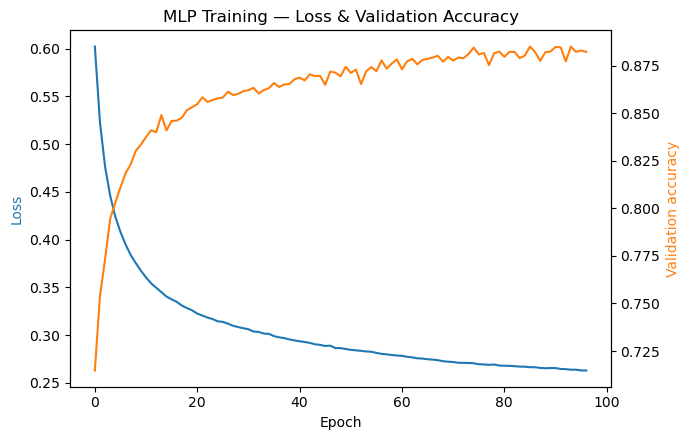

In [12]:
fig, ax1 = plt.subplots(figsize=(7, 4.5))
ax1.plot(mlp.loss_curve_, color="tab:blue", label="Training loss")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss", color="tab:blue")
if hasattr(mlp, "validation_scores_") and mlp.validation_scores_:
    ax2 = ax1.twinx()
    ax2.plot(mlp.validation_scores_, color="tab:orange", label="Validation accuracy")
    ax2.set_ylabel("Validation accuracy", color="tab:orange")
plt.title("MLP Training — Loss & Validation Accuracy")
plt.tight_layout(); plt.savefig("../reports/loss_curve.png", dpi=200); plt.show()

### Confusion Matrix

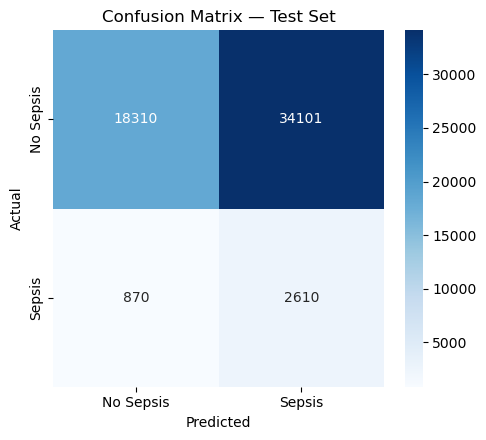

In [13]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Sepsis", "Sepsis"], yticklabels=["No Sepsis", "Sepsis"], ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title("Confusion Matrix — Test Set")
plt.tight_layout(); plt.savefig("../reports/confusion_matrix.png", dpi=200); plt.show()

### ROC Curve (AUC)

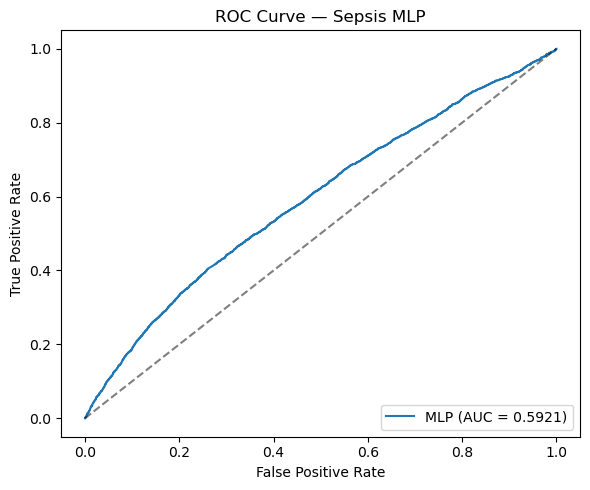

In [14]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"MLP (AUC = {test_auc:.4f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Sepsis MLP"); plt.legend(loc="lower right")
plt.tight_layout(); plt.savefig("../reports/roc_curve.png", dpi=200); plt.show()

### Precision-Recall curve (Average Precision)

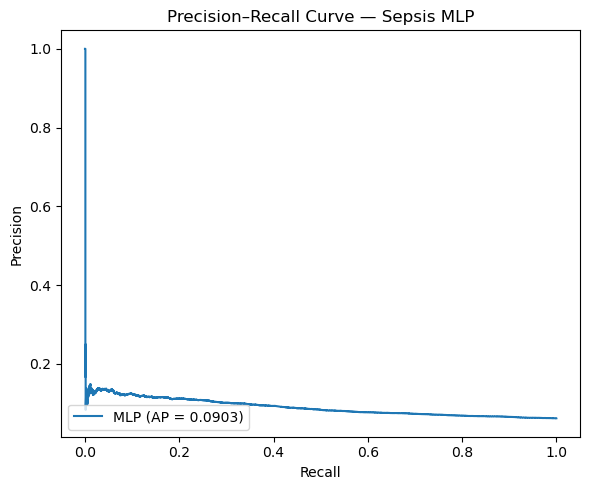

In [15]:
prec_arr, rec_arr, _ = precision_recall_curve(y_test, y_proba)
plt.figure(figsize=(6, 5))
plt.plot(rec_arr, prec_arr, label=f"MLP (AP = {test_ap:.4f})")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision–Recall Curve — Sepsis MLP"); plt.legend(loc="lower left")
plt.tight_layout(); plt.savefig("../reports/pr_curve.png", dpi=200); plt.show()

### 5b. Evaluasi Berbasis Pasien

Evaluasi per jam yang dilakukan di atas merupakan metrik operasional utama sistem peringatan dini, yaitu seberapa sering alarm berbunyi di jam yang tepat. Namun evaluasi berbasis pasien diperlukan untuk menjawab pertanyaan yang berbeda: apakah pasien yang akhirnya mengalami sepsis memang mendapat skor risiko yang lebih tinggi secara keseluruhan dibanding yang tidak.

Agregasi dilakukan dengan mengambil rata-rata tiga probabilitas tertinggi setelah temporal smoothing per pasien. Pendekatan ini lebih robust terhadap spike tunggal namun tetap sensitif terhadap periode kritis. Evaluasi di tingkat pasien melengkapi gambaran per jam dengan menunjukkan bahwa model secara keseluruhan berhasil membedakan pasien sepsis dari yang tidak, bukan hanya menghasilkan alarm di jam yang tepat.

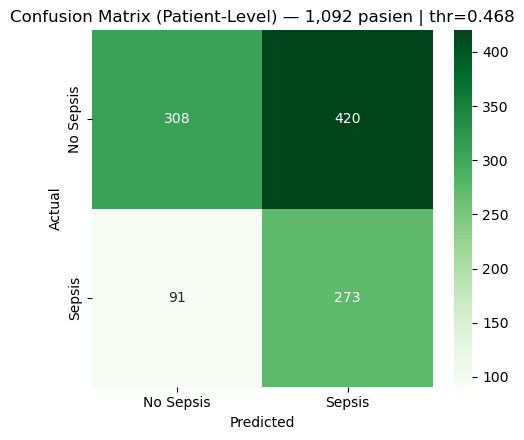

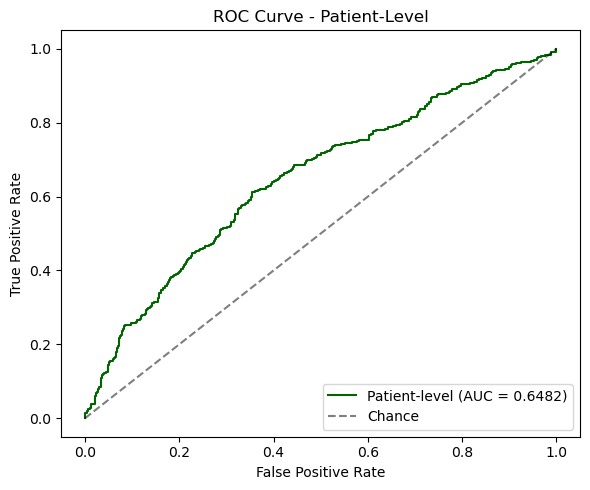

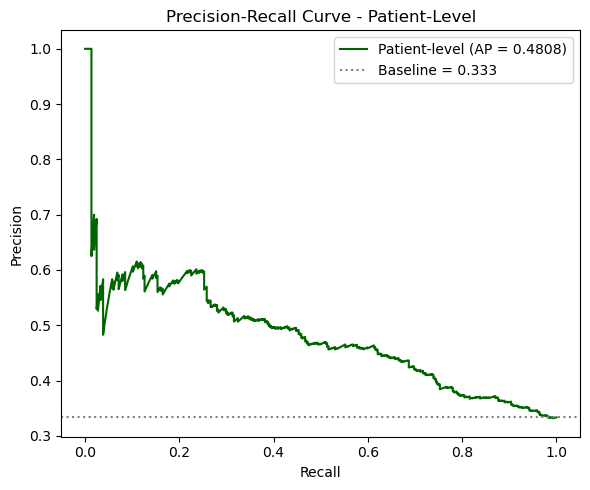

Per-hour   : Recall=0.750  Spec=0.349  AUC=0.592  (n=55,891 rows)
Per-patient: Recall=0.750  Spec=0.423  AUC=0.648  (n=1,092 pasien)


In [16]:
os.makedirs("../reports", exist_ok=True)

fpr_p, tpr_p, _ = roc_curve(pid_y, pid_proba)
prec_arr_p, rec_arr_p, _ = precision_recall_curve(pid_y, pid_proba)
ap_p  = average_precision_score(pid_y, pid_proba)
auc_p = roc_auc_score(pid_y, pid_proba)

cm_p = confusion_matrix(pid_y, pid_pred)
fig, ax = plt.subplots(figsize=(5, 4.5))
sns.heatmap(cm_p, annot=True, fmt="d", cmap="Greens",
            xticklabels=["No Sepsis", "Sepsis"],
            yticklabels=["No Sepsis", "Sepsis"], ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix (Patient-Level) — {len(pid_y):,} pasien | thr={pat_threshold:.3f}")
plt.tight_layout()
plt.savefig("../reports/patient_confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

plt.figure(figsize=(6, 5))
plt.plot(fpr_p, tpr_p, color="darkgreen", label=f"Patient-level (AUC = {auc_p:.4f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Chance")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Patient-Level")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../reports/patient_roc_curve.png", dpi=200, bbox_inches="tight")
plt.show()

plt.figure(figsize=(6, 5))
plt.plot(rec_arr_p, prec_arr_p, color="darkgreen", label=f"Patient-level (AP = {ap_p:.4f})")
plt.axhline(y=pid_y.mean(), linestyle=":", color="gray",
            label=f"Baseline = {pid_y.mean():.3f}")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Patient-Level")
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig("../reports/patient_pr_curve.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Per-hour   : Recall={test_rec_h:.3f}  Spec={test_spec_h:.3f}  AUC={test_auc_h:.3f}  (n={len(y_test):,} rows)")
print(f"Per-patient: Recall={test_rec_p:.3f}  Spec={test_spec_p:.3f}  AUC={test_auc_p:.3f}  (n={len(pid_y):,} pasien)")

## 6. Explainability dengan SHAP

Setelah MLP terlatih dan tervalidasi, analisis SHAP (KernelExplainer) digunakan untuk menjelaskan bagaimana model memprediksi sepsis. Pertanyaan utama yang ditanyakan dalam proses ini adalah apakah fitur biologis yang mendominasi (Lactate, O2Sat, BUN, Hgb, dll.) atau ada shortcut non-biologis yang terpakai?

Konfigurasi yang digunakan:
- SHAP_SAMPLE_SIZE = 500 baris evaluasi dari X_test
- BACKGROUND_SIZE = 50 baris baseline dari X_train
- NSAMPLES = 100 permutasi per baris evaluasi

In [35]:
SHAP_SAMPLE_SIZE = 500
BACKGROUND_SIZE  = 50
NSAMPLES         = 100
RANDOM_STATE     = 42

X_train_scaled = X_train
X_test_scaled  = X_test

rng = np.random.default_rng(RANDOM_STATE)
bg_idx = rng.choice(X_train_scaled.shape[0], size=BACKGROUND_SIZE, replace=False)

pos_test_idx = np.flatnonzero(y_test == 1)
neg_test_idx = np.flatnonzero(y_test == 0)
n_each = SHAP_SAMPLE_SIZE // 2
ev_idx = np.concatenate([
    rng.choice(pos_test_idx, size=min(n_each, len(pos_test_idx)), replace=False),
    rng.choice(neg_test_idx, size=min(n_each, len(neg_test_idx)), replace=False),
])
rng.shuffle(ev_idx)

background  = X_train_scaled[bg_idx]
eval_sample = X_test_scaled[ev_idx]
eval_labels = y_test[ev_idx]

print(f"X_train: {X_train_scaled.shape} | X_test: {X_test_scaled.shape} | features: {len(feature_names)}")
print(f"background : {background.shape}")
print(f"eval_sample: {eval_sample.shape} | pos={int(eval_labels.sum())} neg={int((1-eval_labels).sum())}")

X_train: (403866, 48) | X_test: (55891, 48) | features: 48
background : (50, 48)
eval_sample: (500, 48) | pos=250 neg=250


In [36]:
import random

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

t0 = time.time()
explainer = shap.KernelExplainer(mlp.predict_proba, background)
shap_values = explainer.shap_values(eval_sample, nsamples=NSAMPLES)
elapsed = time.time() - t0

if isinstance(shap_values, list):
    shap_pos = shap_values[1]
else:
    sv_arr = np.asarray(shap_values)
    shap_pos = sv_arr[:, :, 1] if sv_arr.ndim == 3 else sv_arr

print(f"SHAP selesai dalam {elapsed:.1f}s")
print(f"Matriks SHAP positif (Sepsis=1): {shap_pos.shape}")

100%|██████████| 500/500 [00:07<00:00, 65.89it/s]

SHAP selesai dalam 7.6s
Matriks SHAP positif (Sepsis=1): (500, 48)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_7924\4240932141.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_pos, eval_sample, feature_names=feature_names, show=False)


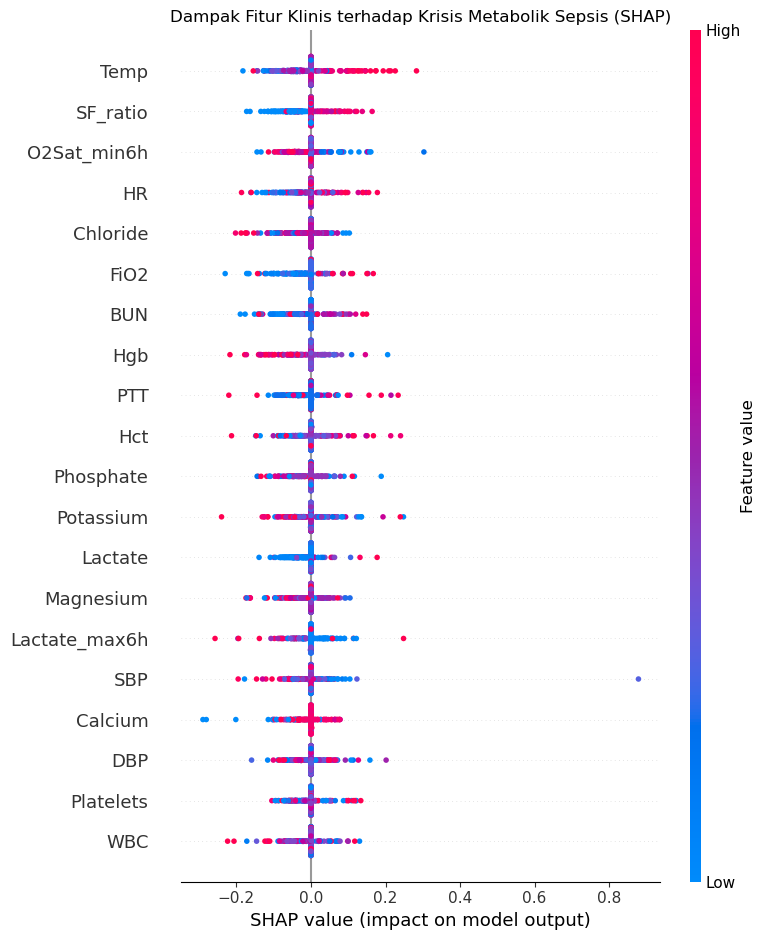

In [37]:
os.makedirs("../reports", exist_ok=True)
plt.figure()
shap.summary_plot(shap_pos, eval_sample, feature_names=feature_names, show=False)
plt.title("Dampak Fitur Klinis terhadap Krisis Metabolik Sepsis (SHAP)")
plt.tight_layout()
plt.savefig("../reports/shap_summary.png", dpi=200, bbox_inches="tight")
plt.show()

In [38]:
mean_abs = np.abs(shap_pos).mean(axis=0)
order = np.argsort(mean_abs)[::-1]

print("Top 10 fitur paling berpengaruh (mean |SHAP|):")
print(f"{'Rank':>4}  {'Fitur':<20s}  {'mean|SHAP|':>12s}")
for rank, j in enumerate(order[:10], 1):
    print(f"{rank:>4}  {feature_names[j]:<20s}  {mean_abs[j]:>12.6f}")

Top 10 fitur paling berpengaruh (mean |SHAP|):
Rank  Fitur                   mean|SHAP|
   1  Temp                      0.027578
   2  SF_ratio                  0.020496
   3  O2Sat_min6h               0.016026
   4  HR                        0.015868
   5  Chloride                  0.015332
   6  FiO2                      0.014837
   7  BUN                       0.014617
   8  Hgb                       0.014441
   9  PTT                       0.012602
  10  Hct                       0.012362


### Temuan SHAP

1. Dua fitur rekayasa yang merepresentasikan hipoksia jaringan muncul di Top 10 mean SHAP, yaitu SF_ratio di posisi 2 dan O2Sat_min6h di posisi 5. Ini mengkonfirmasi bahwa model mengandalkan trajektori oksigenasi 6 jam terakhir dalam mendeteksi krisis, sesuai dengan pilar hipoksia jaringan pada judul penelitian.

2. Temp menempati posisi pertama karena disregulasi suhu tubuh merupakan salah satu kriteria definitif Sepsis-3 dan frekuensi pengukurannya yang tinggi memberikan sinyal diskriminatif yang konsisten sepanjang stay pasien.

3. Lactate tidak muncul di Top 10 meski merupakan marker metabolik utama. Hal ini disebabkan sparsity Lactate yang sangat tinggi, sekitar 97% missing sebelum imputasi, sehingga sebagian besar nilainya berasal dari baseline fisiologis 1.0 mmol/L setelah forward fill dan menekan variasi diskriminatif yang dibutuhkan SHAP untuk mengukur dampak fitur.